# Cross-Country Climate Comparison and Vulnerability Ranking

This notebook compares daily NASA POWER climate data for five African countries: Ethiopia, Kenya, Sudan, Tanzania, and Nigeria. It combines locally cleaned country datasets, compares temperature and precipitation patterns, measures extreme heat and drought frequency, and ranks relative climate vulnerability for COP32-oriented discussion.

## COP32 Context

COP32 is expected to keep adaptation finance, resilience planning, food security, water stress, and climate justice at the center of African climate policy. This analysis frames country-level signals in that context: warming pressure, rainfall reliability, drought exposure, and the frequency of extreme heat days.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

for directory in [RAW_DIR, PROCESSED_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

START_DATE = "20150101"
END_DATE = "20260331"
PARAMETERS = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M"]
EXPECTED_RAW_COLUMNS = {"date", *PARAMETERS}

COUNTRIES = {
    "Ethiopia": {"city": "Addis Ababa", "latitude": 8.9806, "longitude": 38.7578},
    "Kenya": {"city": "Nairobi", "latitude": -1.2921, "longitude": 36.8219},
    "Nigeria": {"city": "Abuja", "latitude": 9.0765, "longitude": 7.3986},
    "Sudan": {"city": "Khartoum", "latitude": 15.5007, "longitude": 32.5599},
    "Tanzania": {"city": "Dodoma", "latitude": -6.1630, "longitude": 35.7516},
}

SEASON_BY_MONTH = {
    12: "DJF", 1: "DJF", 2: "DJF",
    3: "MAM", 4: "MAM", 5: "MAM",
    6: "JJA", 7: "JJA", 8: "JJA",
    9: "SON", 10: "SON", 11: "SON",
}

## Create or Load Cleaned Country Datasets

Each country is stored as a local cleaned CSV under `data/processed/`. If a cleaned file is missing, the notebook downloads the raw NASA POWER daily data, cleans it, exports the cleaned CSV locally, and then loads it back for the combined analysis. These CSV files are ignored by Git. The loading functions validate country metadata, expected columns, API payload structure, and non-empty datasets before analysis continues.

In [2]:
def slugify(name: str) -> str:
    return name.lower().replace(" ", "_")


def validate_country_metadata(country: str, meta: dict) -> None:
    required_keys = {"city", "latitude", "longitude"}
    missing_keys = required_keys - set(meta)
    if missing_keys:
        raise ValueError(f"{country} metadata is missing: {sorted(missing_keys)}")


def fetch_nasa_power(country: str, meta: dict) -> pd.DataFrame:
    validate_country_metadata(country, meta)
    raw_path = RAW_DIR / f"{slugify(country)}_nasa_power_daily_2015_2026.csv"
    if raw_path.exists():
        raw = pd.read_csv(raw_path, parse_dates=["date"])
    else:
        endpoint = "https://power.larc.nasa.gov/api/temporal/daily/point"
        params = {
            "parameters": ",".join(PARAMETERS),
            "community": "AG",
            "longitude": meta["longitude"],
            "latitude": meta["latitude"],
            "start": START_DATE,
            "end": END_DATE,
            "format": "JSON",
        }
        try:
            response = requests.get(endpoint, params=params, timeout=60)
            response.raise_for_status()
            payload = response.json()["properties"]["parameter"]
        except (requests.RequestException, KeyError, ValueError) as exc:
            raise RuntimeError(f"NASA POWER request failed for {country} or returned an unexpected schema") from exc
        raw = pd.DataFrame(payload).rename_axis("date").reset_index()
        raw["date"] = pd.to_datetime(raw["date"], format="%Y%m%d")
        raw.to_csv(raw_path, index=False)

    missing_columns = EXPECTED_RAW_COLUMNS - set(raw.columns)
    if missing_columns:
        raise ValueError(f"{country} raw data is missing columns: {sorted(missing_columns)}")
    if raw.empty:
        raise ValueError(f"{country} raw dataset is empty")
    return raw


def clean_country_data(country: str, meta: dict) -> Path:
    processed_path = PROCESSED_DIR / f"{slugify(country)}_daily_cleaned.csv"
    if processed_path.exists():
        return processed_path

    df = fetch_nasa_power(country, meta)
    df.columns = df.columns.str.lower()
    df = df.replace(-999, np.nan)
    df = df.drop_duplicates(subset="date").sort_values("date")
    df = df.set_index("date").asfreq("D")
    if df.index.hasnans:
        raise ValueError(f"{country} date parsing produced missing timestamps")
    numeric_cols = df.select_dtypes(include="number").columns
    df[numeric_cols] = df[numeric_cols].interpolate(method="time", limit_direction="both")
    df = df.reset_index()
    df["country"] = country
    df["location"] = meta["city"]
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["month_name"] = df["date"].dt.month_name().str[:3]
    df["season"] = df["month"].map(SEASON_BY_MONTH)
    df.to_csv(processed_path, index=False)
    return processed_path


cleaned_paths = {country: clean_country_data(country, meta) for country, meta in COUNTRIES.items()}
cleaned_paths

{'Ethiopia': WindowsPath('C:/Users/Administrator/Documents/Codex/2026-04-29/files-mentioned-by-the-user-african/climate-challenge-week0/data/processed/ethiopia_daily_cleaned.csv'),
 'Kenya': WindowsPath('C:/Users/Administrator/Documents/Codex/2026-04-29/files-mentioned-by-the-user-african/climate-challenge-week0/data/processed/kenya_daily_cleaned.csv'),
 'Nigeria': WindowsPath('C:/Users/Administrator/Documents/Codex/2026-04-29/files-mentioned-by-the-user-african/climate-challenge-week0/data/processed/nigeria_daily_cleaned.csv'),
 'Sudan': WindowsPath('C:/Users/Administrator/Documents/Codex/2026-04-29/files-mentioned-by-the-user-african/climate-challenge-week0/data/processed/sudan_daily_cleaned.csv'),
 'Tanzania': WindowsPath('C:/Users/Administrator/Documents/Codex/2026-04-29/files-mentioned-by-the-user-african/climate-challenge-week0/data/processed/tanzania_daily_cleaned.csv')}

In [3]:
country_frames = []
for country, path in cleaned_paths.items():
    country_df = pd.read_csv(path, parse_dates=["date"])
    if country_df.empty:
        raise ValueError(f"Cleaned dataset for {country} is empty")
    country_frames.append(country_df)

climate = pd.concat(country_frames, ignore_index=True)
climate = climate.sort_values(["country", "date"]).reset_index(drop=True)

load_summary = climate.groupby("country").agg(
    rows=("date", "size"),
    start_date=("date", "min"),
    end_date=("date", "max"),
    missing_temperature=("t2m", lambda s: int(s.isna().sum())),
    missing_precipitation=("prectotcorr", lambda s: int(s.isna().sum())),
).reset_index()

display(load_summary)
display(climate.head())

,country,rows,start_date,end_date,missing_temperature,missing_precipitation
0,Ethiopia,4108,2015-01-01,2026-03-31,0,0
1,Kenya,4108,2015-01-01,2026-03-31,0,0
2,Nigeria,4108,2015-01-01,2026-03-31,0,0
3,Sudan,4108,2015-01-01,2026-03-31,0,0
4,Tanzania,4108,2015-01-01,2026-03-31,0,0


,date,t2m,t2m_max,t2m_min,prectotcorr,rh2m,ws2m,country,location,year,month,month_name,season
0,2015-01-01,11.73,22.75,3.44,0.0,41.79,2.73,Ethiopia,Addis Ababa,2015,1,Jan,Bega
1,2015-01-02,12.30,24.01,4.09,0.0,33.29,2.39,Ethiopia,Addis Ababa,2015,1,Jan,Bega
2,2015-01-03,12.49,24.17,3.97,0.0,33.83,1.77,Ethiopia,Addis Ababa,2015,1,Jan,Bega
3,2015-01-04,14.08,23.78,6.90,0.0,38.84,0.87,Ethiopia,Addis Ababa,2015,1,Jan,Bega
4,2015-01-05,14.06,23.15,7.32,0.0,47.07,1.34,Ethiopia,Addis Ababa,2015,1,Jan,Bega


## Temperature Comparison

The annual mean temperature trend and summary statistics compare long-term thermal exposure across the five countries.

,mean_temperature_c,median_temperature_c,mean_daily_max_c,hottest_day_c
country,,,,
Sudan,28.75,29.15,36.77,45.96
Nigeria,26.03,25.59,31.94,42.11
Tanzania,22.63,22.50,29.47,37.05
Kenya,20.43,20.36,27.83,34.27
Ethiopia,16.07,16.05,23.20,30.93


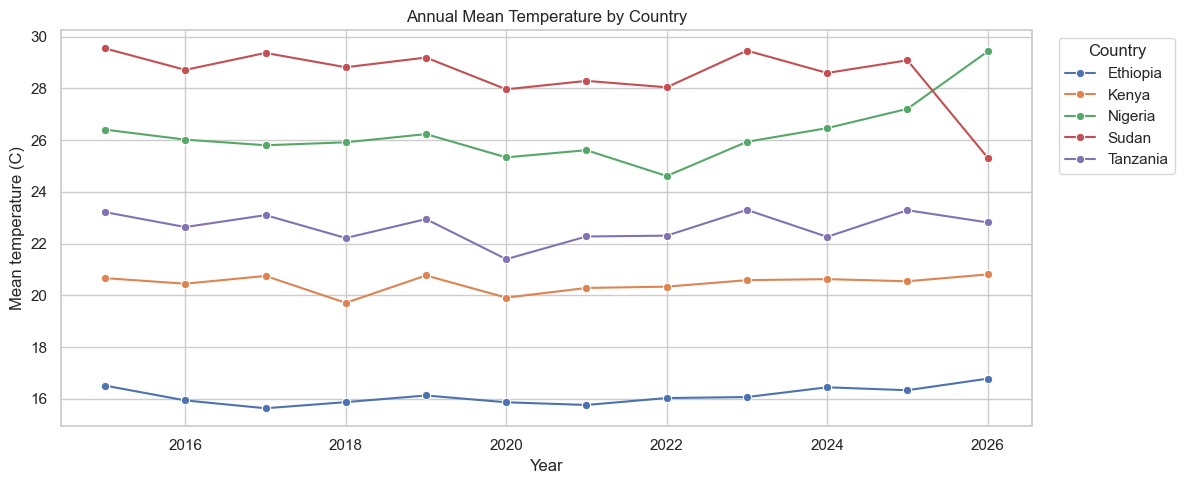

In [4]:
annual_temperature = climate.groupby(["country", "year"], as_index=False).agg(
    mean_temperature_c=("t2m", "mean"),
    mean_max_temperature_c=("t2m_max", "mean"),
)

temperature_summary = climate.groupby("country").agg(
    mean_temperature_c=("t2m", "mean"),
    median_temperature_c=("t2m", "median"),
    mean_daily_max_c=("t2m_max", "mean"),
    hottest_day_c=("t2m_max", "max"),
).round(2).sort_values("mean_temperature_c", ascending=False)

display(temperature_summary)

ax = sns.lineplot(data=annual_temperature, x="year", y="mean_temperature_c", hue="country", marker="o")
ax.set_title("Annual Mean Temperature by Country")
ax.set_xlabel("Year")
ax.set_ylabel("Mean temperature (C)")
plt.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Temperature interpretation:** The country lines show different baseline climates as well as year-to-year variability. Countries with consistently higher mean and maximum temperatures face stronger heat-health, crop stress, and cooling-demand pressures in adaptation planning.

## Precipitation Comparison

Precipitation is compared using annual totals, monthly seasonal distributions, and summary statistics. Rainfall reliability matters directly for water supply, agriculture, and drought preparedness.

,mean_annual_precipitation_mm,driest_year_mm,wettest_year_mm,precipitation_cv
country,,,,
Ethiopia,1245.893,164.81,1746.66,0.329
Nigeria,1123.090,7.49,1760.93,0.388
Tanzania,878.280,576.92,1377.09,0.288
Kenya,502.570,273.65,787.36,0.327
Sudan,220.420,0.00,492.92,0.603


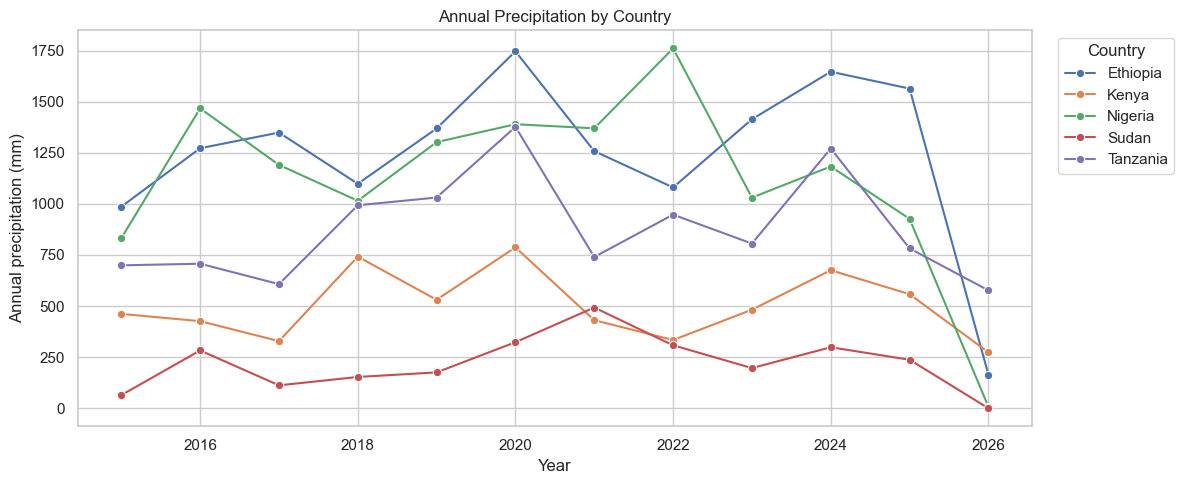

In [5]:
annual_precipitation = climate.groupby(["country", "year"], as_index=False).agg(
    annual_precipitation_mm=("prectotcorr", "sum"),
)

precipitation_summary = annual_precipitation.groupby("country").agg(
    mean_annual_precipitation_mm=("annual_precipitation_mm", "mean"),
    driest_year_mm=("annual_precipitation_mm", "min"),
    wettest_year_mm=("annual_precipitation_mm", "max"),
    precipitation_cv=("annual_precipitation_mm", lambda s: s.std() / s.mean()),
).round(3).sort_values("mean_annual_precipitation_mm", ascending=False)

display(precipitation_summary)

ax = sns.lineplot(data=annual_precipitation, x="year", y="annual_precipitation_mm", hue="country", marker="o")
ax.set_title("Annual Precipitation by Country")
ax.set_xlabel("Year")
ax.set_ylabel("Annual precipitation (mm)")
plt.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

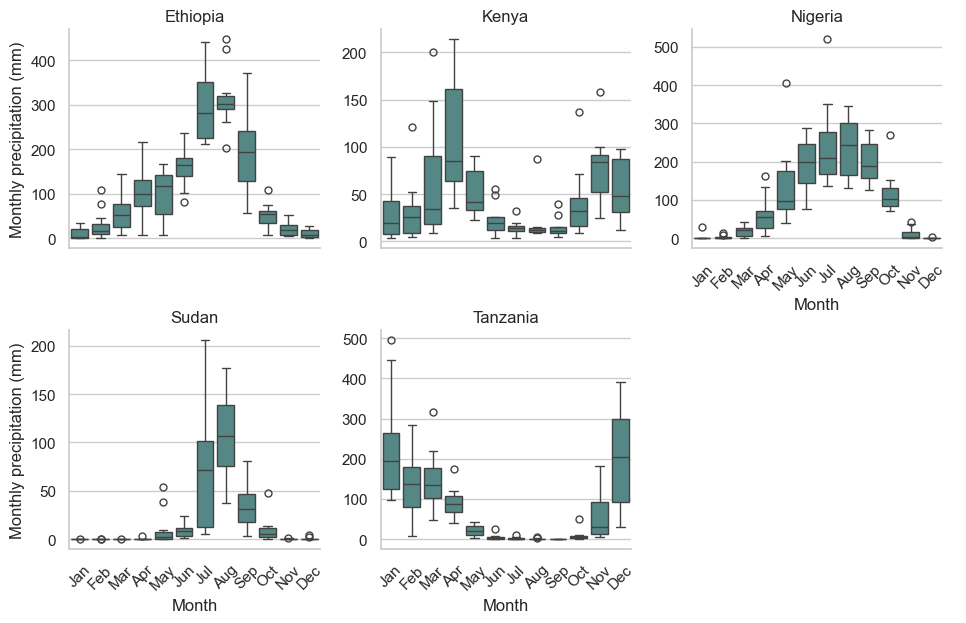

In [6]:
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_precipitation = climate.groupby(["country", "year", "month", "month_name"], as_index=False).agg(
    monthly_precipitation_mm=("prectotcorr", "sum"),
)

g = sns.catplot(
    data=monthly_precipitation,
    x="month_name",
    y="monthly_precipitation_mm",
    col="country",
    kind="box",
    order=month_order,
    col_wrap=3,
    height=3.2,
    sharey=False,
    color="#4d8f8b",
)
g.set_axis_labels("Month", "Monthly precipitation (mm)")
g.set_titles("{col_name}")
for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Precipitation interpretation:** The countries differ not only in total rainfall but also in seasonality and variability. High variability or highly concentrated rainy seasons imply greater planning risk when rainfall arrives late, weak, or in damaging bursts.

## Extreme Heat and Drought Frequency

Extreme heat is defined using each country's 95th percentile of daily maximum temperature, which compares unusual heat relative to the local baseline. Drought-like days are days with precipitation below 1 mm, and drought months are months below each country's 20th percentile of monthly rainfall.

,heat_threshold_c,extreme_heat_days,extreme_heat_day_rate,dry_day_rate,drought_months,drought_month_rate
country,,,,,,
Kenya,31.620,210,0.051,0.689,27,0.200
Tanzania,34.450,208,0.051,0.702,27,0.200
Ethiopia,28.106,206,0.050,0.526,27,0.200
Nigeria,38.316,206,0.050,0.556,27,0.200
Sudan,43.396,206,0.050,0.900,55,0.407


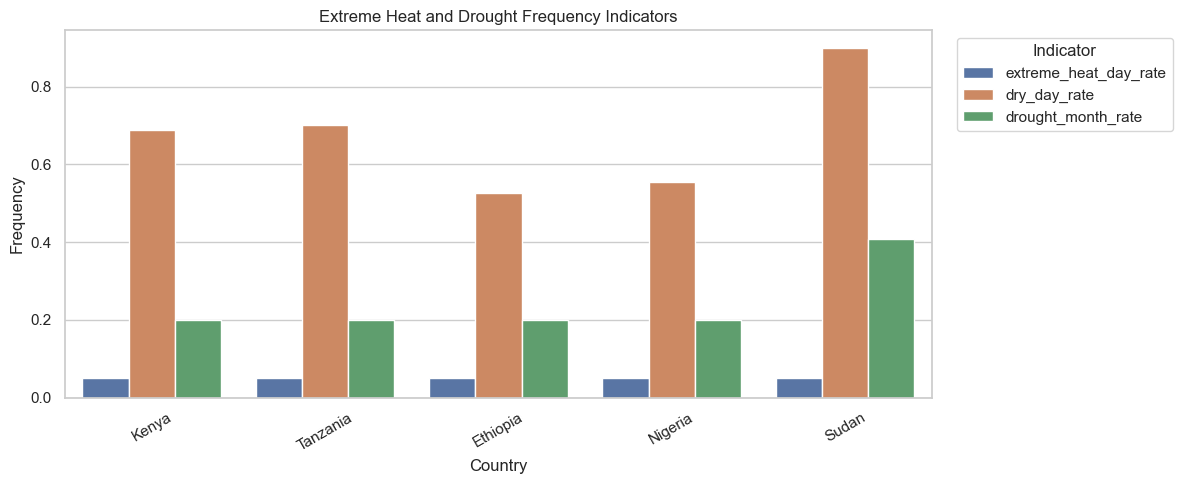

In [7]:
heat_thresholds = climate.groupby("country")["t2m_max"].quantile(0.95).rename("heat_threshold_c")
climate = climate.merge(heat_thresholds, on="country", how="left")
climate["extreme_heat_day"] = climate["t2m_max"] >= climate["heat_threshold_c"]
climate["dry_day"] = climate["prectotcorr"] < 1.0

monthly_country_precip = climate.groupby(["country", "year", "month"], as_index=False).agg(
    monthly_precipitation_mm=("prectotcorr", "sum"),
)
drought_thresholds = monthly_country_precip.groupby("country")["monthly_precipitation_mm"].quantile(0.20).rename("drought_month_threshold_mm")
monthly_country_precip = monthly_country_precip.merge(drought_thresholds, on="country", how="left")
monthly_country_precip["drought_month"] = monthly_country_precip["monthly_precipitation_mm"] <= monthly_country_precip["drought_month_threshold_mm"]

extreme_summary = climate.groupby("country").agg(
    heat_threshold_c=("heat_threshold_c", "first"),
    extreme_heat_days=("extreme_heat_day", "sum"),
    extreme_heat_day_rate=("extreme_heat_day", "mean"),
    dry_day_rate=("dry_day", "mean"),
).join(
    monthly_country_precip.groupby("country").agg(
        drought_months=("drought_month", "sum"),
        drought_month_rate=("drought_month", "mean"),
    )
).round(3).sort_values("extreme_heat_day_rate", ascending=False)

display(extreme_summary)

plot_extremes = extreme_summary.reset_index().melt(
    id_vars="country",
    value_vars=["extreme_heat_day_rate", "dry_day_rate", "drought_month_rate"],
    var_name="indicator",
    value_name="frequency",
)
ax = sns.barplot(data=plot_extremes, x="country", y="frequency", hue="indicator")
ax.set_title("Extreme Heat and Drought Frequency Indicators")
ax.set_xlabel("Country")
ax.set_ylabel("Frequency")
ax.tick_params(axis="x", rotation=30)
plt.legend(title="Indicator", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Extreme events interpretation:** The heat and drought indicators highlight different kinds of exposure. A country can have high dry-day frequency even if its rainy season is intense, which makes both annual totals and event frequency necessary for vulnerability assessment.

## Climate Vulnerability Ranking

The ranking below is a relative screening index for these five countries, not a full socioeconomic vulnerability model. It combines five normalized climate indicators: mean temperature, annual temperature trend, precipitation variability, dry-day frequency, and drought-month frequency.

,rank,country,vulnerability_score,mean_temperature_c,temperature_trend_c_per_year,precipitation_cv,dry_day_rate,drought_month_rate
0,1,Sudan,0.800,28.75,-0.169,0.603,0.900,0.407
1,2,Nigeria,0.437,26.03,0.154,0.388,0.556,0.200
2,3,Tanzania,0.302,22.63,0.000,0.288,0.702,0.200
3,4,Kenya,0.296,20.43,0.018,0.327,0.689,0.200
4,5,Ethiopia,0.158,16.07,0.045,0.329,0.526,0.200


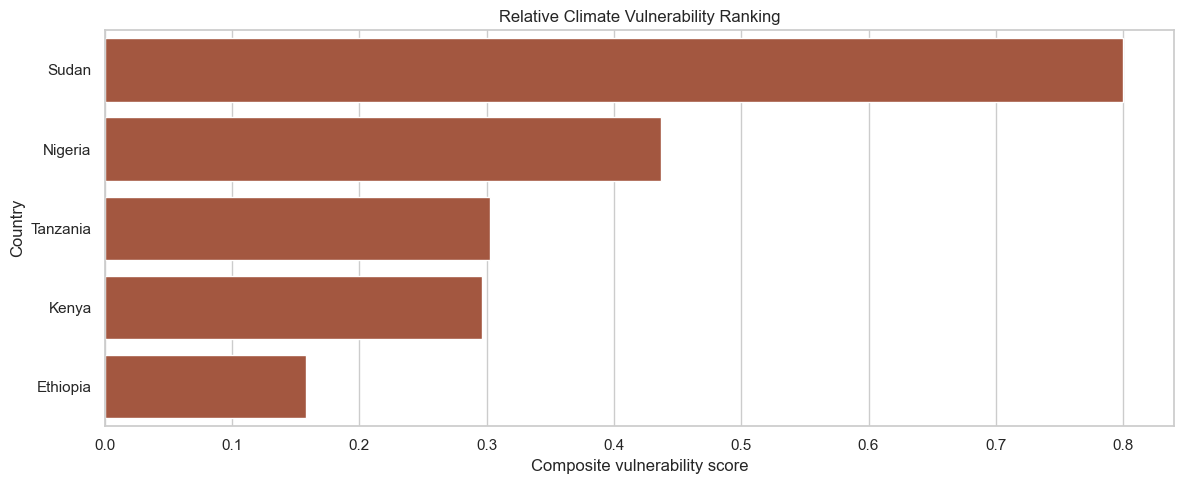

In [8]:
def slope_per_year(group: pd.DataFrame, value_col: str) -> float:
    x = group["year"].to_numpy(dtype=float)
    y = group[value_col].to_numpy(dtype=float)
    if len(np.unique(x)) < 2:
        return np.nan
    return float(np.polyfit(x, y, 1)[0])


temperature_trends = annual_temperature.groupby("country").apply(
    lambda g: slope_per_year(g, "mean_temperature_c"), include_groups=False
).rename("temperature_trend_c_per_year")

ranking_inputs = temperature_summary.join(precipitation_summary).join(extreme_summary).join(temperature_trends)

vulnerability_features = [
    "mean_temperature_c",
    "temperature_trend_c_per_year",
    "precipitation_cv",
    "dry_day_rate",
    "drought_month_rate",
]

scaled = ranking_inputs[vulnerability_features].copy()
for column in vulnerability_features:
    min_value = scaled[column].min()
    max_value = scaled[column].max()
    if np.isclose(max_value, min_value):
        scaled[column] = 0.0
    else:
        scaled[column] = (scaled[column] - min_value) / (max_value - min_value)

ranking_inputs["vulnerability_score"] = scaled.mean(axis=1)
vulnerability_ranking = ranking_inputs.sort_values("vulnerability_score", ascending=False).reset_index()
vulnerability_ranking.insert(0, "rank", range(1, len(vulnerability_ranking) + 1))

display(vulnerability_ranking[[
    "rank",
    "country",
    "vulnerability_score",
    "mean_temperature_c",
    "temperature_trend_c_per_year",
    "precipitation_cv",
    "dry_day_rate",
    "drought_month_rate",
]].round(3))

ax = sns.barplot(data=vulnerability_ranking, x="vulnerability_score", y="country", color="#b44e2f")
ax.set_title("Relative Climate Vulnerability Ranking")
ax.set_xlabel("Composite vulnerability score")
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()

## COP32 Observations

- Countries with higher heat exposure and positive temperature trends should prioritize heat-health response, climate-smart agriculture, and cooling-resilient urban planning.
- Countries with high precipitation variability or drought-month frequency need stronger early warning systems, water storage, and drought-contingency financing.
- COP32 adaptation discussions should avoid treating African climate risk as uniform; the five-country comparison shows distinct heat, rainfall, and drought profiles.
- The vulnerability ranking is useful for prioritization, but final COP32 policy recommendations should add population exposure, poverty, infrastructure, agriculture dependence, and adaptive-capacity indicators.